---
downloads:
  - url: https://colab.research.google.com/github/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard/blob/main/LS100_00B_Python-Fundamentals/LS100_Python-Fundamentals_00_Notebook03_Data-Visualization_LastUpdate-202606.ipynb
    title: Open in Colab
  - url: https://codespaces.new/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard?devcontainer_path=.devcontainer%2Fdevcontainer.json
    title: Open in GitHub Codespaces
  - file: LS100_Python-Fundamentals_00_Notebook03_Data-Visualization_LastUpdate-202606.ipynb
    title: Download notebook
---


# Python Essentials for Research in Behavioral Sciences: Visualizing Data

In Notebooks 01 and 02 you learned to store, load, and automate work on data. The very next thing any researcher does with a fresh dataset is **look at it**. A good figure does in one glance what a table of numbers cannot: it reveals trends, exposes outliers, and makes a finding *convincing* to other people.

This notebook builds your visualization toolkit from the ground up, always with research data in mind. We will start with **matplotlib** (the foundation every other Python plotting library is built on), then layer on **seaborn** (faster, prettier statistical plots), and finish with a peek at **interactive Plotly**. Along the way we build the specific figures this course needs — time series of joint angles, distributions across conditions, and the **ethogram**, the behavioural biologist's timeline of what an animal is doing, moment to moment.

By the end you will be able to choose the right plot for a question, make it clear and honest, and save it at a quality you can drop into a report.


## How to Use This Notebook Well

* **Run every cell yourself**, top to bottom — the dataset built in Section 0 is reused everywhere.
* For each plot, ask *what question does this answer?* before reading the code.
* Change things. Swap a column, change a colour, add a title. Plots are the most rewarding place to experiment because you see the result instantly.
* **Mini Challenges** and **Checkpoints** are for you to attempt before moving on.

> We will lean on matplotlib first (Sections 1–2), treat seaborn as a faster layer on top (Section 3), and only peek at Plotly at the end (4.3). That way you are never juggling three libraries at once.

---


### Table of Content:

0. [Setup & Our Dataset](#section-0)

1. [Why Visualize? + The matplotlib Mental Model](#section-1)
    - [1.1. Explore vs. Communicate (and why summary stats can lie)](#11)
    - [1.2. The Figure / Axes Mental Model](#12)
    - [1.3. Your First Plot: An Angle Over Time](#13)

2. [Core Plot Types for Behavioral Data](#section-2)
    - [2.1. Line Plots & Time Series](#21)
    - [2.2. Scatter Plots & Relationships](#22)
    - [2.3. Distributions: Histograms](#23)
    - [2.4. Boxplots: Comparing Groups](#24)
    - [2.5. Bar Plots: Group Means with Error Bars](#25)

3. [Faster & Prettier — pandas `.plot()` and seaborn](#section-3)
    - [3.1. One-Line Plots from a DataFrame](#31)
    - [3.2. seaborn for Statistical Plots](#32)
    - [3.3. Small Multiples (Faceting)](#33)

4. [Visualizing Behavior Specifically](#section-4)
    - [4.1. The Ethogram (Behavior Timeline)](#41)
    - [4.2. Heatmaps](#42)
    - [4.3. A Peek at Interactive Plotly](#43)

5. [Making Figures Publication-Ready](#section-5)
    - [5.1. Labels, Titles, Legends, Ticks](#51)
    - [5.2. Color & Accessibility](#52)
    - [5.3. Saving Figures for Reports](#53)

6. [Bridge + Weekly Challenge](#section-6)

---


<a id="section-0"></a>
## Section 0: Setup & Our Dataset

First the usual interpreter check and our imports. The three plotting libraries we use:
* **matplotlib** — the foundation. We import its `pyplot` module as `plt` (the universal convention).
* **seaborn** (`sns`) — statistical plots built on top of matplotlib.
* **plotly express** (`px`) — interactive plots, used briefly in 4.3.


In [1]:
import sys
print("Interpreter:", sys.executable)
print("Python     :", sys.version.split()[0])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy     :", np.__version__)
print("pandas    :", pd.__version__)
print("matplotlib:", __import__("matplotlib").__version__)
print("seaborn   :", sns.__version__)


Interpreter: /Users/souvikmandal/python_venv/StatEnv/bin/python
Python     : 3.12.12
numpy     : 2.3.5
pandas    : 2.3.3
matplotlib: 3.10.7
seaborn   : 0.13.2


Rather than depend on an external file, we **simulate** a small behavioural dataset so this notebook runs anywhere. Imagine three athletes (A, B, C), each recorded over two sessions. For every video **frame** we have two joint angles (knee, elbow) and a coded **behaviour** (rest / walk / run). We set a random seed so everyone gets the same numbers.

This "long" or **tidy** layout — one row per observation, one column per variable — is the format both pandas and seaborn are happiest with.

In [2]:
rng = np.random.default_rng(42)   # reproducible randomness

FPS = 30
rows = []
for athlete in ["A", "B", "C"]:
    for session in [1, 2]:
        n = 180                                   # 180 frames = 6 seconds at 30 fps
        frame = np.arange(n)
        t = frame / FPS                           # time in seconds

        # Knee angle: a smooth oscillation (like a repeated movement) + noise.
        base = 110 + (5 if athlete == "B" else 0) # athlete B holds a wider angle
        knee = base + 25 * np.sin(2 * np.pi * t / 2) + rng.normal(0, 3, n)

        # Elbow angle: loosely follows the knee, plus its own noise.
        elbow = 90 + 0.4 * (knee - base) + rng.normal(0, 4, n)

        # Behaviour state, coded from the knee angle band (just for illustration).
        behavior = np.where(knee > 130, "run",
                    np.where(knee > 100, "walk", "rest"))

        for i in range(n):
            rows.append({"athlete": athlete, "session": session,
                         "frame": int(frame[i]), "time_s": round(float(t[i]), 3),
                         "knee_angle": round(float(knee[i]), 2),
                         "elbow_angle": round(float(elbow[i]), 2),
                         "behavior": str(behavior[i])})

df = pd.DataFrame(rows)
print("Shape:", df.shape)
df.head()


Shape: (1080, 7)


,athlete,session,frame,time_s,knee_angle,elbow_angle,behavior
0,A,1,0,0.000,110.91,95.59,walk
1,A,1,1,0.033,109.49,90.67,walk
2,A,1,2,0.067,117.45,91.34,walk
3,A,1,3,0.100,120.55,98.64,walk
4,A,1,4,0.133,114.32,93.44,walk


We will also build a small **per-trial summary** table — one row per athlete per session — for the plots that compare *groups* rather than *frames* (bar and box plots in 2.4–2.5).

In [3]:
summary = (df.groupby(["athlete", "session"])
             .agg(mean_knee=("knee_angle", "mean"),
                  mean_elbow=("elbow_angle", "mean"),
                  pct_running=("behavior", lambda s: (s == "run").mean() * 100))
             .reset_index())
summary


,athlete,session,mean_knee,mean_elbow,pct_running
0,A,1,109.829556,90.084944,17.777778
1,A,2,109.944778,89.435833,19.444444
2,B,1,114.858611,90.229833,31.666667
3,B,2,114.895000,89.995389,27.777778
4,C,1,109.639778,89.371611,18.888889
5,C,2,109.404167,89.874667,18.888889


<a id="section-1"></a>
## Section 1: Why Visualize? + The matplotlib Mental Model


<a id="11"></a>
### 1.1. Concept: Explore vs. Communicate (and why summary stats can lie)

Visualization serves two distinct goals:
* **Exploration** — *for you*: quick, rough plots to understand your data and catch problems.
* **Communication** — *for others*: polished figures that make a point clearly and honestly.

Why not just report the mean and standard deviation? Because **very different data can share the same summary statistics**. The classic demonstration is *Anscombe's quartet*: datasets with nearly identical means, variances, and correlations that look completely different when plotted. Below is a small version of that idea — two datasets with the *same* mean and standard deviation but very different shapes.


In [64]:
# Two 'reaction time' samples with matching mean and (nearly) matching spread.
clustered = np.array([0.50, 0.52, 0.49, 0.51, 0.98])   # four tight + one outlier
spread    = np.array([0.32, 0.53, 0.60, 0.67, 0.90])   # genuinely spread out

# 'name' is the text label ("clustered" or "spread"); 'data' is the matching numpy array.
# The loop goes through both samples and prints each sample's mean and standard deviation.
for name, data in [("clustered", clustered), ("spread", spread)]:
    print(f"Data file: {name:10s} mean={data.mean():.2f}  std={data.std():.2f}")

# The ":10s" makes the field width of at least 10 characters to align the text labels in the output.
# The ":.2f" formats the mean and std to show only 2 decimal places for cleaner output.

Data file: clustered  mean=0.60  std=0.19
Data file: spread     mean=0.60  std=0.19


In [65]:
# Reminder of the for loop for two variables:
name_1 = "Amazon"
name_2 = "Google"
for name, data in [("Company 1", name_1), ("Company 2", name_2)]:
    print(f"Company position: {name:10s}| Company name: {data:8s} | Length of Company name: {len(data)}")

Company position: Company 1 | Company name: Amazon   | Length of Company name: 6
Company position: Company 2 | Company name: Google   | Length of Company name: 6


#### Ploting the data

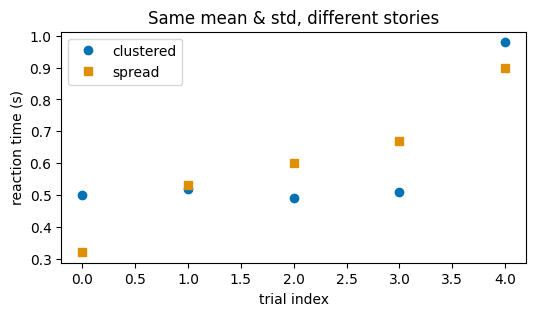

In [ ]:
# Create one figure and one axes to draw on.
fig, ax = plt.subplots(figsize=(6, 3))

# Plot each dataset with a different marker style and a label on the corner.
ax.plot(clustered, "o", label="clustered") # "o" is the marker style for circles
ax.plot(spread,    "s", label="spread") # "s" is the marker style for squares

# Label axes so the plot is readable.
ax.set_xlabel("trial index"); ax.set_ylabel("reaction time (s)")

ax.set_title("Same mean & std, different stories") # Add a title and legend to explain what is shown.
ax.legend()
plt.show() # Render the figure in the notebook output.


As you can see, the plot from the datasets that gave same stats reveals two different trends.

**The lesson:** plot your data while you start building intuition from your data. Exploration is not optional polish; it is an indispensable part of data analysis.

<a id="12"></a>
### 1.2. Concept: The Figure / Axes Mental Model

Almost all confusion with matplotlib disappears once you hold this picture:

* A **Figure** is the whole canvas — the window or image file.
* An **Axes** is a single plot *inside* that figure (the box with x- and y-axes). A figure can hold several Axes side by side.

The clean, modern way to start is `fig, ax = plt.subplots()`. You then call **methods on `ax`** to draw and label: `ax.plot(...)`, `ax.set_xlabel(...)`, `ax.set_title(...)`. This "explicit" style scales smoothly from one plot to many.

**Key Characteristics:**
* `fig, ax = plt.subplots()` creates one figure with one Axes.
* `plt.subplots(nrows, ncols)` returns a grid of Axes for small multiples (Section 3.3).
* `figsize=(width, height)` is in inches.
* End an exploratory cell with `plt.show()` to render the figure.


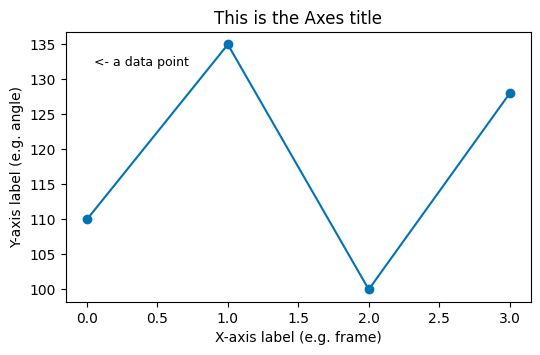

In [67]:
# The anatomy of a figure, labelled.
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot([0, 1, 2, 3], [110, 135, 100, 128], marker="o")
ax.set_title("This is the Axes title")
ax.set_xlabel("X-axis label (e.g. frame)")
ax.set_ylabel("Y-axis label (e.g. angle)")
ax.text(0.05, 132, "<- a data point", fontsize=9)
plt.show()


<a id="13"></a>
### 1.3. Your First Research Plot: An Angle Over Time

A **line plot** is the natural choice when the x-axis is *time* (or frames) and you want to see how a signal evolves. Let us plot one athlete's knee angle across one session.


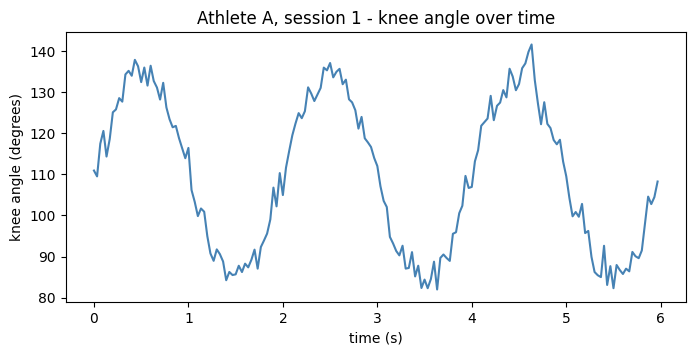

In [68]:
# Pull a single athlete + session out of the tidy DataFrame.
one = df[(df["athlete"] == "A") & (df["session"] == 1)]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(one["time_s"], one["knee_angle"], color="steelblue", linewidth=1.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("knee angle (degrees)")
ax.set_title("Athlete A, session 1 - knee angle over time")
plt.show()


> **Mini Challenge 1.3.** Plot athlete A's **elbow** angle on the same time axis. Then try plotting both knee and elbow on one Axes with two `ax.plot(...)` calls and a legend.

<a id="section-2"></a>
## Section 2: Core Plot Types for Behavioral Data

Five plot types cover the vast majority of research figures. For each, the key skill is matching the **plot to the question**.


<a id="21"></a>
### 2.1. Line Plots & Time Series — *"how does it change over time?"*

To compare several athletes, draw one line per athlete on the same Axes. A `for` loop over groups keeps the code short and readable.


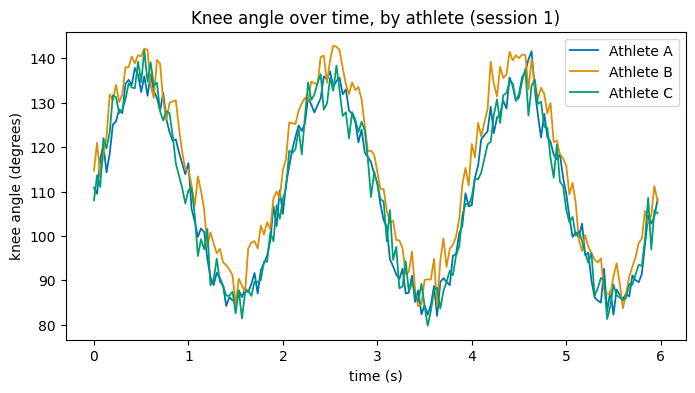

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))

# One line per athlete, session 1 only.
for athlete, g in df[df["session"] == 1].groupby("athlete"):
    ax.plot(g["time_s"], g["knee_angle"], label=f"Athlete {athlete}", linewidth=1.3)

ax.set_xlabel("time (s)")
ax.set_ylabel("knee angle (degrees)")
ax.set_title("Knee angle over time, by athlete (session 1)")
ax.legend()
plt.show()


<a id="22"></a>
### 2.2. Scatter Plots & Relationships — *"do two measures move together?"*

A **scatter plot** puts one variable on each axis, one dot per observation. It is how you see whether two measures are *related*. The **correlation coefficient** `r` (from `np.corrcoef`) summarises that relationship in one number from -1 to +1.


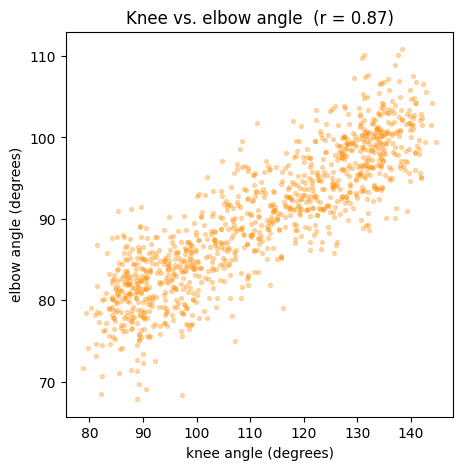

In [70]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df["knee_angle"], df["elbow_angle"], s=8, alpha=0.3, color="darkorange")
ax.set_xlabel("knee angle (degrees)")
ax.set_ylabel("elbow angle (degrees)")

# Correlation: corrcoef returns a 2x2 matrix; the off-diagonal [0,1] is r.
r = np.corrcoef(df["knee_angle"], df["elbow_angle"])[0, 1]
ax.set_title(f"Knee vs. elbow angle  (r = {r:.2f})")
plt.show()


> `alpha=0.3` makes the dots semi-transparent so that *overlapping* points show up as darker regions — a simple trick for dense data.

<a id="23"></a>
### 2.3. Distributions: Histograms — *"what values are common?"*

A **histogram** sorts values into **bins** and shows how many fall in each. It reveals the *shape* of a variable: where it centres, how spread out it is, whether it is skewed or has two peaks. The number of bins is a judgement call — too few hides structure, too many turns it into noise.


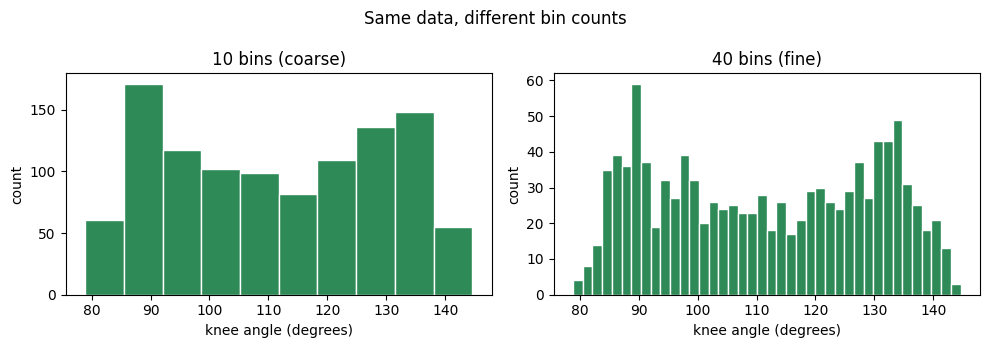

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(df["knee_angle"], bins=10, color="seagreen", edgecolor="white")
axes[0].set_title("10 bins (coarse)")

axes[1].hist(df["knee_angle"], bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("40 bins (fine)")

for ax in axes:
    ax.set_xlabel("knee angle (degrees)"); ax.set_ylabel("count")
fig.suptitle("Same data, different bin counts")
plt.tight_layout()
plt.show()


<a id="24"></a>
### 2.4. Boxplots: Comparing Groups — *"how do conditions differ?"*

A **boxplot** summarises a distribution as a box (the middle 50% of the data), a line (the median), whiskers (the range), and dots (outliers). Lining up one box per group makes differences between conditions jump out.


/var/folders/xl/3brx3y1d71n15p4qb7psl0580000gq/T/ipykernel_8968/1080852975.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_state, labels=states)


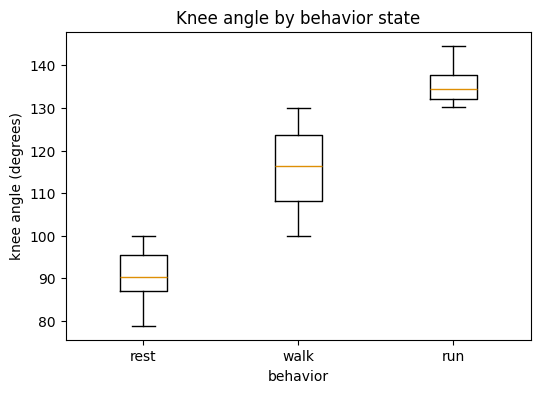

In [72]:
# Distribution of knee angle within each behaviour state.
states = ["rest", "walk", "run"]
data_by_state = [df[df["behavior"] == s]["knee_angle"] for s in states]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(data_by_state, labels=states)
ax.set_xlabel("behavior")
ax.set_ylabel("knee angle (degrees)")
ax.set_title("Knee angle by behavior state")
plt.show()


<a id="25"></a>
### 2.5. Bar Plots: Group Means with Error Bars — *"which group scored higher?"*

A **bar plot** compares a single summary number (often a mean) across groups. Always pair the bar with an **error bar** (here, the standard deviation) so the reader can see the *spread*, not just the average — a bar alone can be misleading.


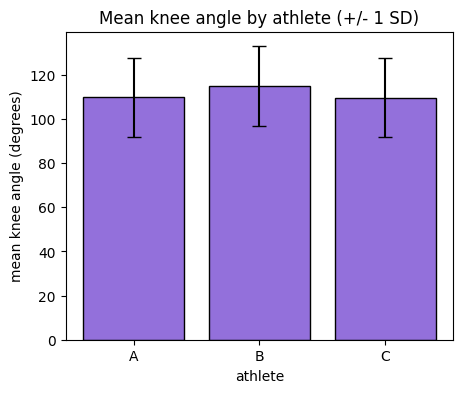

In [73]:
# Mean knee angle per athlete, with standard deviation as the error bar.
means = df.groupby("athlete")["knee_angle"].mean()
stds  = df.groupby("athlete")["knee_angle"].std()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(means.index, means.values, yerr=stds.values,
       capsize=5, color="mediumpurple", edgecolor="black")
ax.set_xlabel("athlete")
ax.set_ylabel("mean knee angle (degrees)")
ax.set_title("Mean knee angle by athlete (+/- 1 SD)")
plt.show()


> **Checkpoint 2.** For each of the five plot types, say the *question* it answers in a few words: line = change over time, scatter = relationship, histogram = distribution shape, boxplot = compare distributions across groups, bar = compare a single number across groups. Matching plot to question is the whole game.

---


<a id="section-3"></a>
## Section 3: Faster & Prettier — pandas `.plot()` and seaborn

Everything so far was pure matplotlib, so you understand what is happening underneath. Now we meet two shortcuts that produce nicer plots with far less code.


<a id="31"></a>
### 3.1. One-Line Plots Straight from a DataFrame

pandas DataFrames and Series carry a built-in `.plot()` method that calls matplotlib for you. It is perfect for a quick look during exploration.


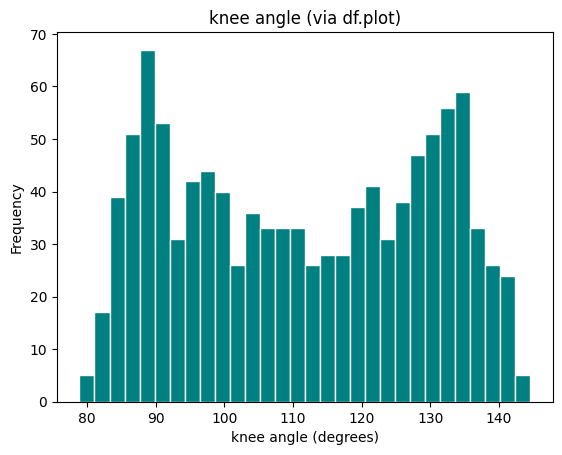

In [74]:
# A Series knows how to plot itself. Same histogram as 2.3, in one line.
df["knee_angle"].plot(kind="hist", bins=30, title="knee angle (via df.plot)",
                      color="teal", edgecolor="white")
plt.xlabel("knee angle (degrees)")
plt.show()


<a id="32"></a>
### 3.2. Concept: seaborn for Statistical Plots

**seaborn** is built on matplotlib but designed for *statistical* plots of *tidy* DataFrames. Its big idea: you pass the whole DataFrame plus the **column names** for `x`, `y`, and `hue` (the grouping colour), and seaborn handles the splitting, colouring, and legend automatically.

**Key Characteristics:**
* You name columns (`x="time_s"`), you do not pre-slice the data.
* `hue="athlete"` automatically draws and colours one group per athlete and builds the legend.
* It assumes **tidy data** (one row per observation) — exactly the shape we built in Section 0.


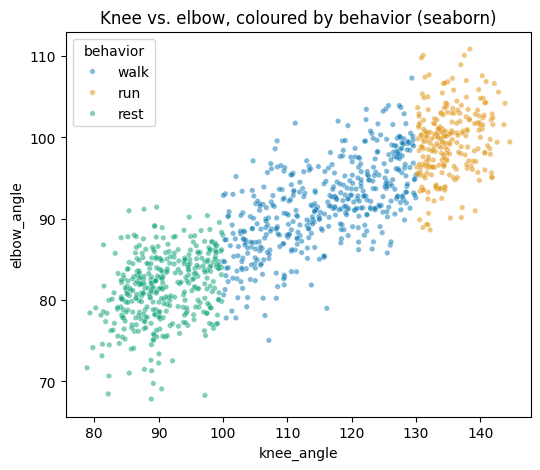

In [75]:
# A seaborn scatter, coloured by behaviour, in a single call.
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="knee_angle", y="elbow_angle",
                hue="behavior", alpha=0.5, s=15, ax=ax)
ax.set_title("Knee vs. elbow, coloured by behavior (seaborn)")
plt.show()


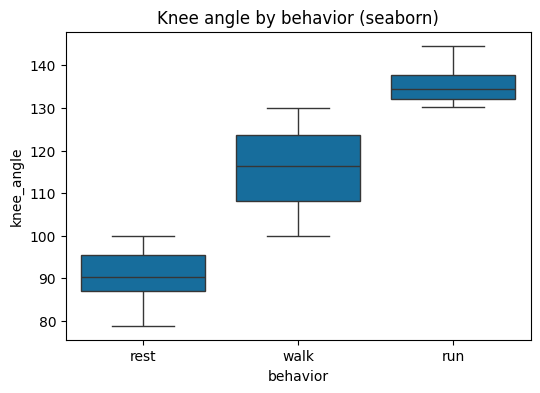

In [76]:
# Compare the boxplot from 2.4 -- seaborn needs just one line and adds colour.
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="behavior", y="knee_angle",
            order=["rest", "walk", "run"], ax=ax)
ax.set_title("Knee angle by behavior (seaborn)")
plt.show()


<a id="33"></a>
### 3.3. Small Multiples (Faceting)

When you want the *same* plot repeated for each group, seaborn's **faceting** draws a grid automatically. `sns.relplot(..., col="athlete")` makes one panel per athlete. Comparing panels side by side is often clearer than cramming everything onto one Axes.


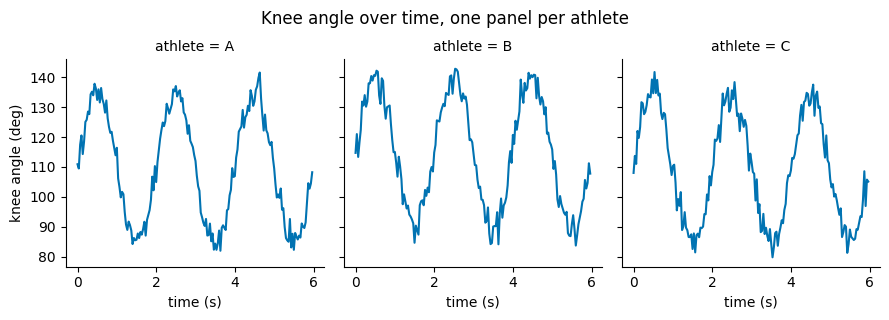

In [77]:
# One time-series panel per athlete, session 1. height/aspect control panel size.
g = sns.relplot(data=df[df["session"] == 1], x="time_s", y="knee_angle",
                col="athlete", kind="line", height=3, aspect=1.0)
g.set_axis_labels("time (s)", "knee angle (deg)")
g.figure.suptitle("Knee angle over time, one panel per athlete", y=1.05)
plt.show()


> **Mini Challenge 3.** Recreate the seaborn scatter in 3.2 but facet it with `col="athlete"` so each athlete gets their own panel. Which athlete shows the tightest knee-elbow relationship?

<a id="section-4"></a>
## Section 4: Visualizing Behavior Specifically

Three figures you will reach for again and again when the *subject itself* is behaviour.


<a id="41"></a>
### 4.1. The Ethogram (Behavior Timeline)

An **ethogram** is the behavioural scientist's signature plot: a timeline showing *which discrete behaviour* an individual is performing at each moment. It turns a column of labels (`rest`, `walk`, `run`) into an instantly readable band of colour over time — perfect for spotting how long behaviours last and how they alternate.

We build it by coding each behaviour as an integer and drawing the sequence as a coloured strip with `imshow`.


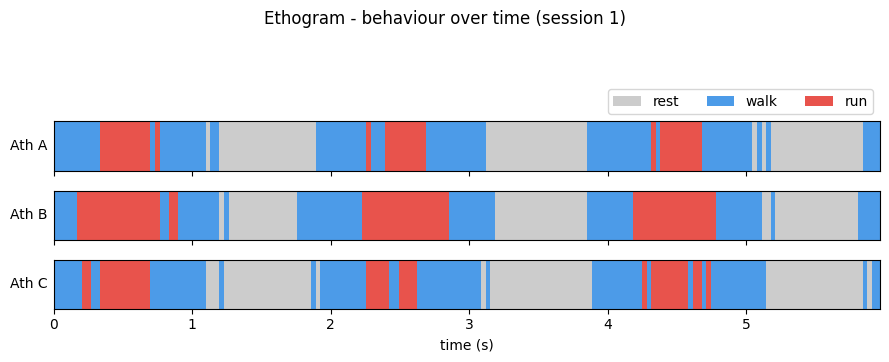

In [78]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

states = ["rest", "walk", "run"]
state_to_int = {s: i for i, s in enumerate(states)}     # rest->0, walk->1, run->2
colors = ["#cccccc", "#4c9be8", "#e8534c"]              # grey, blue, red
cmap = ListedColormap(colors)

fig, axes = plt.subplots(3, 1, figsize=(9, 3.5), sharex=True)
for ax, athlete in zip(axes, ["A", "B", "C"]):
    seq = df[(df["athlete"] == athlete) & (df["session"] == 1)]
    coded = seq["behavior"].map(state_to_int).to_numpy().reshape(1, -1)   # 1 x frames
    ax.imshow(coded, aspect="auto", cmap=cmap, vmin=0, vmax=2,
              extent=[seq["time_s"].min(), seq["time_s"].max(), 0, 1])
    ax.set_yticks([]); ax.set_ylabel(f"Ath {athlete}", rotation=0, labelpad=18, va="center")

axes[-1].set_xlabel("time (s)")
legend = [Patch(facecolor=c, label=s) for c, s in zip(colors, states)]
axes[0].legend(handles=legend, ncol=3, bbox_to_anchor=(1.0, 1.8), loc="upper right")
fig.suptitle("Ethogram - behaviour over time (session 1)", y=1.02)
plt.tight_layout()
plt.show()


Read each strip left to right: a glance tells you that the athletes cycle between rest, walk, and run, and roughly how much time each spends running. That is the power of an ethogram.

<a id="42"></a>
### 4.2. Heatmaps — *"which variables relate to which?"*

A **heatmap** colours the cells of a matrix by value. A common use is a **correlation matrix**: every pair of numeric variables, coloured by how strongly they correlate. seaborn's `heatmap` with `annot=True` writes the numbers in too.


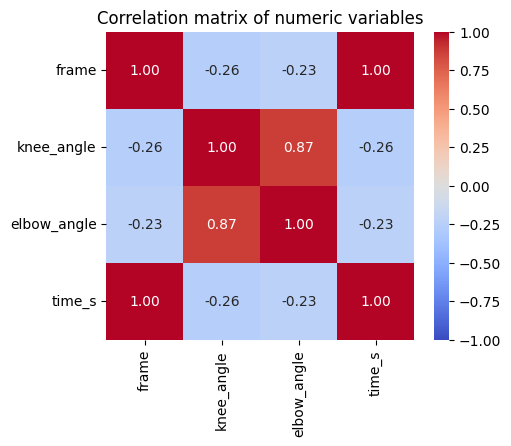

In [79]:
corr = df[["frame", "knee_angle", "elbow_angle", "time_s"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix of numeric variables")
plt.show()


<a id="43"></a>
### 4.3. A Peek at Interactive Plotly

Sometimes you want to *hover* over a point to read its exact values, or zoom into a busy time series. **Plotly** makes interactive figures with very little code. `plotly.express` (imported as `px`) mirrors the seaborn style: pass the DataFrame and column names.

Run the cell and hover over the line — each point shows the frame and angle. (This is a light taste; matplotlib and seaborn remain your everyday tools.)


In [80]:
import plotly.express as px

one = df[(df["athlete"] == "A") & (df["session"] == 1)]
fig = px.line(one, x="time_s", y="knee_angle",
              title="Interactive knee angle (hover and zoom)",
              labels={"time_s": "time (s)", "knee_angle": "knee angle (deg)"})
fig.update_layout(height=350)
fig            # displaying the figure object renders it interactively in Jupyter


<a id="section-5"></a>
## Section 5: Making Figures Publication-Ready

An exploratory plot is for you; a communication plot is for your reader. The difference is almost always **labels, colour, and resolution**.


<a id="51"></a>
### 5.1. Labels, Titles, Legends, Ticks — the non-negotiables

A figure a stranger cannot read is not finished. Every plot you share should have: axis labels **with units**, an informative title, a legend if there is more than one series, and readable tick marks. Here is the same line plot, before and after.


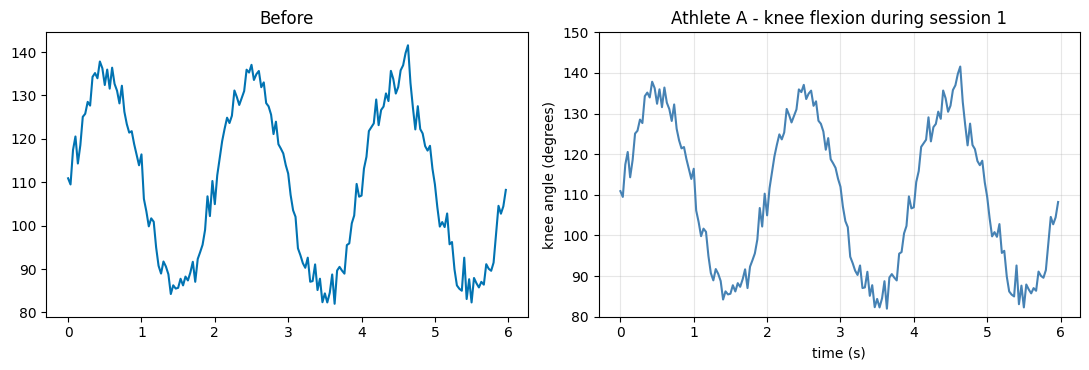

In [81]:
one = df[(df["athlete"] == "A") & (df["session"] == 1)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# BEFORE: technically a plot, but uncommunicative.
axes[0].plot(one["time_s"], one["knee_angle"])
axes[0].set_title("Before")

# AFTER: labelled, titled, sensible limits, a grid for reading values.
axes[1].plot(one["time_s"], one["knee_angle"], color="steelblue", linewidth=1.5)
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("knee angle (degrees)")
axes[1].set_title("Athlete A - knee flexion during session 1")
axes[1].set_ylim(80, 150)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<a id="52"></a>
### 5.2. Concept: Color & Accessibility

Colour carries meaning, so choose it deliberately:
* **Categorical** data (athlete, behaviour) needs *distinct* colours — use a qualitative palette.
* **Ordered/continuous** data (a value from low to high) needs a *sequential* palette where lightness tracks the value.
* Roughly 1 in 12 men has some colour-vision deficiency, so prefer **colorblind-safe** palettes and never rely on red-vs-green alone. seaborn ships a ready-made `"colorblind"` palette.


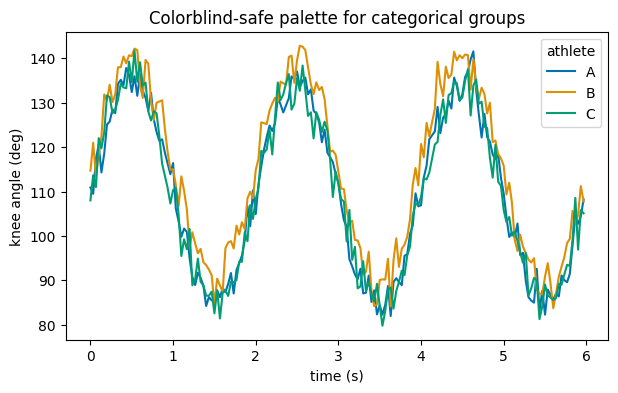

colorblind palette (hex):
['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


In [82]:
# seaborn's colorblind-safe qualitative palette, applied globally.
sns.set_palette("colorblind")

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=df[df["session"] == 1], x="time_s", y="knee_angle",
             hue="athlete", ax=ax)
ax.set_xlabel("time (s)"); ax.set_ylabel("knee angle (deg)")
ax.set_title("Colorblind-safe palette for categorical groups")
plt.show()

# Preview the palette itself.
print("colorblind palette (hex):")
print(sns.color_palette("colorblind").as_hex())


<a id="53"></a>
### 5.3. Saving Figures for Reports

To put a figure in a report, save it with `fig.savefig(...)`. Two arguments matter most:
* `dpi` — dots per inch; **300** is the standard for crisp print/figures.
* `bbox_inches="tight"` — trims surrounding whitespace.

Save as **PNG** for documents and slides; save as **PDF** or **SVG** when you need infinitely scalable *vector* graphics.


Saved 'example_figure.png' (300 dpi).


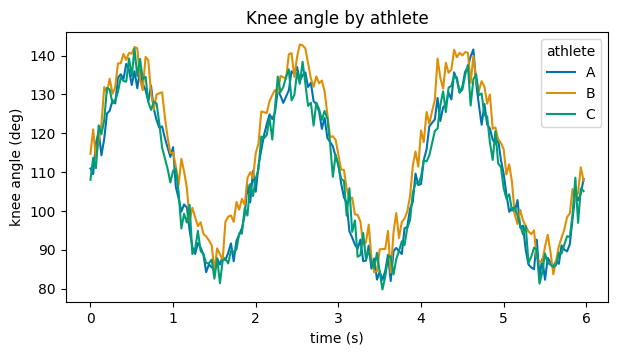

In [83]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.lineplot(data=df[df["session"] == 1], x="time_s", y="knee_angle",
             hue="athlete", ax=ax)
ax.set_xlabel("time (s)"); ax.set_ylabel("knee angle (deg)")
ax.set_title("Knee angle by athlete")

# Save a high-resolution copy next to this notebook.
fig.savefig("example_figure.png", dpi=300, bbox_inches="tight")
# fig.savefig("example_figure.pdf", bbox_inches="tight")   # vector version
print("Saved 'example_figure.png' (300 dpi).")
plt.show()


<a id="section-6"></a>
## Section 6: Bridge + Weekly Challenge

You can now turn a table of numbers into a figure that *shows* something — a trend, a difference, an outlier, a behavioural timeline. Two of those are worth holding onto:

* The **outliers and patterns** a plot reveals are exactly what you will later *quantify* with statistics (Notebook on mixed-effects models). Plotting first tells you which test even makes sense.
* Real recordings are large — hundreds of thousands of frames. Drawing and summarising them efficiently is where the **computational thinking** of Notebook 04 pays off.

> **Weekly Challenge.** Using `df` (or a dataset of your own), build a **single figure with three panels** that tells one story about an athlete:
> 1. a **time series** of knee angle (Section 2.1),
> 2. a **histogram** of that same angle (Section 2.3), and
> 3. an **ethogram** of the behaviour over the same window (Section 4.1).
>
> Use `fig, axes = plt.subplots(3, 1, ...)`, label every axis with units, apply a colorblind-safe palette, and save the result at 300 dpi. Aim for a figure a classmate could understand with no explanation from you — that is the real test of a good visualization.

---

*End of Notebook 03. Next: **Notebook 04 - Computational Thinking: Data Structures, Algorithms & Fluency**, where we make the processing behind these figures fast and clean.*
